# Análisis y Clasificación de Clientes para Campañas de Marketing

### Descripción del Proyecto

Este proyecto tiene como objetivo utilizar técnicas de análisis de datos y aprendizaje automático para identificar diferentes segmentos de clientes basados en sus comportamientos de compra y características demográficas. Esto te permitirá desarrollar estrategias de marketing dirigidas y personalizadas. Aplicando métodos de preprocesamiento de datos, reducción de dimensiones, y técnicas de clustering para analizar un conjunto de datos simulado de clientes.


### Datos

Se utiliza un dataset simulado llamado `datos_clientes.csv` que te descargarás en los recursos de esta lección, y que contiene información demográfica y de comportamiento de compra de clientes, como la edad, los ingresos anuales, la puntuación de gasto y la categoría de producto favorito.


### Pasos a seguir

1. **Preprocesamiento de Datos**
2. **Reducción de Dimensiones**
3. **Clustering**: 
4. **Interpretación y Estrategias de Marketing**

## Análisis y Clasificación de Clientes para Campañas de Marketing 

### 1. Preprocesamiento de Datos

In [2]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage

In [3]:
# Cargar los datos
ruta=r"C:\Users\CixoY\Downloads\customer_data.csv"
df=pd.read_csv(ruta)

In [4]:
df

,ID Cliente,Edad,Ingresos Anuales (k$),Puntuación de Gasto (1-100),Categoría de Producto Favorito
0,1,56,89,47,Libros
1,2,69,91,86,Hogar
2,3,46,46,23,Electrónica
3,4,32,28,66,Libros
4,5,60,81,27,Electrónica
...,...,...,...,...,...
195,196,69,77,99,Libros
196,197,30,86,36,Electrónica
197,198,58,65,82,Electrónica
198,199,20,43,96,Alimentos


In [5]:
# Ver información básica del dataset
df.info()
df.isnull()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   ID Cliente                      200 non-null    int64 
 1   Edad                            200 non-null    int64 
 2   Ingresos Anuales (k$)           200 non-null    int64 
 3   Puntuación de Gasto (1-100)     200 non-null    int64 
 4   Categoría de Producto Favorito  200 non-null    object
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,ID Cliente,Edad,Ingresos Anuales (k$),Puntuación de Gasto (1-100),Categoría de Producto Favorito
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
195,False,False,False,False,False
196,False,False,False,False,False
197,False,False,False,False,False
198,False,False,False,False,False


In [6]:
df.describe()

,ID Cliente,Edad,Ingresos Anuales (k$),Puntuación de Gasto (1-100)
count,200.000000,200.00000,200.000000,200.000000
mean,100.500000,43.42500,69.580000,49.910000
std,57.879185,14.94191,29.693808,29.409292
min,1.000000,18.00000,20.000000,1.000000
25%,50.750000,31.00000,43.750000,24.000000
50%,100.500000,43.50000,69.500000,50.000000
75%,150.250000,56.00000,92.500000,74.000000
max,200.000000,69.00000,119.000000,99.000000


In [7]:
df.isnull()

,ID Cliente,Edad,Ingresos Anuales (k$),Puntuación de Gasto (1-100),Categoría de Producto Favorito
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
195,False,False,False,False,False
196,False,False,False,False,False
197,False,False,False,False,False
198,False,False,False,False,False


In [9]:
# Normalizar los datos
normalizado=MinMaxScaler()
cols_a_escalar =df[['Edad','Ingresos Anuales (k$)', 'Puntuación de Gasto (1-100)']]
df_normalizado=normalizado.fit_transform(cols_a_escalar)
df_1=pd.DataFrame(df_normalizado,columns=cols_a_escalar.columns)
df_1

,Edad,Ingresos Anuales (k$),Puntuación de Gasto (1-100)
0,0.745098,0.696970,0.469388
1,1.000000,0.717172,0.867347
2,0.549020,0.262626,0.224490
3,0.274510,0.080808,0.663265
4,0.823529,0.616162,0.265306
...,...,...,...
195,1.000000,0.575758,1.000000
196,0.235294,0.666667,0.357143
197,0.784314,0.454545,0.826531
198,0.039216,0.232323,0.969388


Se fusionan las tablas normalizadas con las de ID cliente y producto favorito

In [10]:
cols_agregar=df[['ID Cliente','Categoría de Producto Favorito']]
df_2=df_1.join(cols_agregar)
df_2
columnas_ordenadas = ['ID Cliente'] + [col for col in df_2.columns if col != 'ID Cliente']
df_2 = df_2[columnas_ordenadas]
df_2

,ID Cliente,Edad,Ingresos Anuales (k$),Puntuación de Gasto (1-100),Categoría de Producto Favorito
0,1,0.745098,0.696970,0.469388,Libros
1,2,1.000000,0.717172,0.867347,Hogar
2,3,0.549020,0.262626,0.224490,Electrónica
3,4,0.274510,0.080808,0.663265,Libros
4,5,0.823529,0.616162,0.265306,Electrónica
...,...,...,...,...,...
195,196,1.000000,0.575758,1.000000,Libros
196,197,0.235294,0.666667,0.357143,Electrónica
197,198,0.784314,0.454545,0.826531,Electrónica
198,199,0.039216,0.232323,0.969388,Alimentos


### 2. Reducción de Dimensiones: PCA

In [11]:
# Aplicar PCA
X_pca = df_2[['Edad', 'Ingresos Anuales (k$)', 'Puntuación de Gasto (1-100)']]
y_pca = df_2['Categoría de Producto Favorito']

In [12]:
from sklearn.metrics import silhouette_score

for k in range(2, 8): # La silueta requiere al menos 2 grupos
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    print(f"Para k={k}, el puntaje de silueta es: {score:.2f}")

Para k=2, el puntaje de silueta es: 0.26
Para k=3, el puntaje de silueta es: 0.27
Para k=4, el puntaje de silueta es: 0.29
Para k=5, el puntaje de silueta es: 0.29
Para k=6, el puntaje de silueta es: 0.29
Para k=7, el puntaje de silueta es: 0.29


Mediante silhouette_score se determina que la cantidad de clusters a usar es de 5, ya que su margen de puntaje no cambia desde que k≥5

In [13]:
x_centrado_pca=X_pca-np.mean(X_pca,axis=0)
pca=PCA(n_components=3)

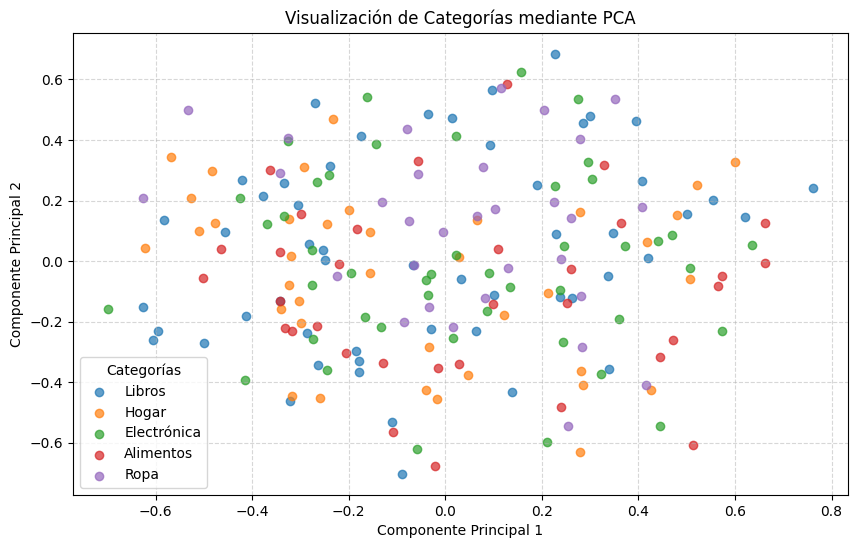

In [ ]:
# 1. Transformar los datos
x_pca_1 = pca.fit_transform(x_centrado_pca)

plt.figure(figsize=(10,6))

# 2. Iterar sobre las categorías ÚNICAS (nombres reales)
categorias_unicas = y_pca.unique()

for cat in categorias_unicas:
    # Filtramos las filas que pertenecen a cada categoría
    plt.scatter(
        x_pca_1[y_pca == cat, 0], 
        x_pca_1[y_pca == cat, 1],
        label=cat,  # Añadimos el nombre para la leyenda
        alpha=0.7   # Un poco de transparencia para ver puntos solapados
    )

plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title="Categorías")
plt.title('Visualización de Categorías mediante PCA')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Tras la reduccion de dimensinalidad de las diferentes variables seleccionadas, se han simplificado a un grafico 2D donde se describen las 200 muestras del dataset coloreado segun la categoria de su producto favorito

### 3. Clustering: K-Means y Clustering Jerárquico

In [17]:
# Aplicar K-Means
kmeans=KMeans(n_clusters=5,random_state=42)
kmeans.fit(X_pca)

,n_clusters,5
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [18]:
centroides=kmeans.cluster_centers_
etiquetas=kmeans.labels_

c:\Users\CixoY\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


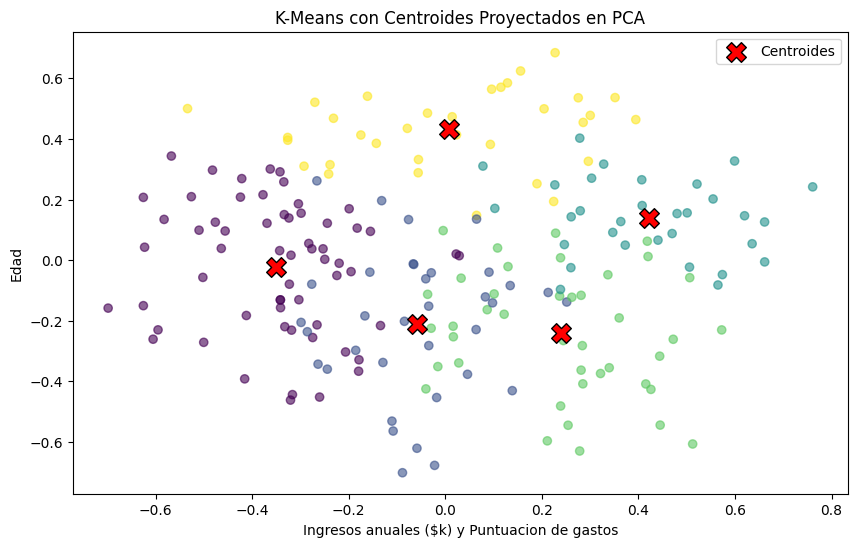

In [ ]:
#Calculamos la media como un simple array de números 
media_x = np.mean(X_pca, axis=0).values

centroides_pca = pca.transform(centroides - media_x)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(x_pca_1[:, 0], x_pca_1[:, 1], c=etiquetas, cmap='viridis', alpha=0.6)

plt.scatter(
    centroides_pca[:, 0], 
    centroides_pca[:, 1], 
    marker='X', s=200, c='red', label='Centroides', edgecolor='black'
)
plt.xlabel('Ingresos anuales ($k) y Puntuacion de gastos')
plt.ylabel('Edad')
plt.title('K-Means con Centroides Proyectados en PCA')
plt.legend()
plt.show()

En el grafico se logra identificar que en promedio la gente mientras es mas joven, gasta mas que la gente de mediana edad, mientras que si son mayores gastan un poco mas de dinero.

In [29]:
# Aplicar Clustering Jerárquico

linked=linkage(x_pca_1,'ward')#compacta los cluster posibles

C:\Users\CixoY\AppData\Local\Temp\ipykernel_2576\84200887.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


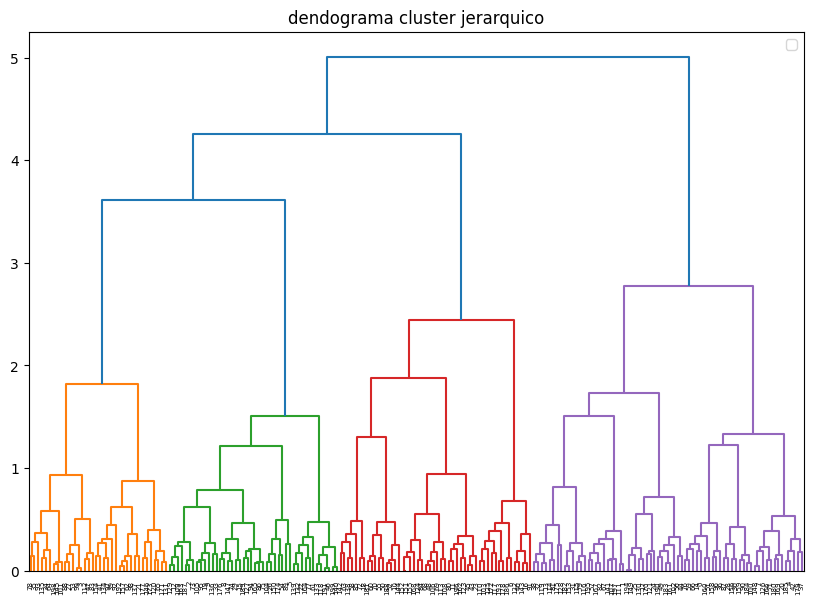

In [30]:
plt.figure(figsize=(10,7))
dendrogram(linked,orientation='top',distance_sort='descending',show_leaf_counts=True)
plt.title('dendograma cluster jerarquico')
plt.legend()

Gracias al grafico de cluster jerarquico se logra ver que la mejor segmentacion de clusters para poder hacer el proceso de clustering

In [ ]:
import pandas as pd

loadings = pd.DataFrame(
    pca.components_.T, 
    columns=['CP1', 'CP2', 'CP3'], # Agregamos CP3 para que coincida con los datos
    index=['Edad', 'Ingresos Anuales (k$)', 'Puntuación de Gasto (1-100)']
)

print("Influencia de las variables en cada componente:")
display(loadings)

Influencia de las variables en cada componente:


,CP1,CP2,CP3
Edad,0.262534,0.825142,-0.500216
Ingresos Anuales (k$),0.732964,0.166623,0.659546
Puntuación de Gasto (1-100),0.627567,-0.539793,-0.561055


### 4. Interpretación y Estrategias de Marketing basadas en los Clusters

In [ ]:
# 1. Creamos un DataFrame temporal con los datos originales 
cluster_info = pd.DataFrame({
    'Cluster': etiquetas,  
    'Edad': df['Edad'],
    'Ingresos': df['Ingresos Anuales (k$)'],
    'Gasto': df['Puntuación de Gasto (1-100)']
})

# 2. Descripción de cada cluster con nombres amigables
print("--- RESUMEN ESTRATÉGICO POR CLUSTER ---")
for cluster in sorted(cluster_info['Cluster'].unique()):
    cluster_data = cluster_info[cluster_info['Cluster'] == cluster]
    print(f"Cluster {cluster}:")
    print(f" - Edad Media: {cluster_data['Edad'].mean():.0f} años")
    print(f" - Ingresos Medios: ${cluster_data['Ingresos'].mean():.2f}k")
    print(f" - Puntuación de Gasto Media: {cluster_data['Gasto'].mean():.2f}/100")
    print("-" * 30)

--- RESUMEN ESTRATÉGICO POR CLUSTER ---
Cluster 0:
 - Edad Media: 36 años
 - Ingresos Medios: $49.20k
 - Puntuación de Gasto Media: 24.83/100
------------------------------
Cluster 1:
 - Edad Media: 42 años
 - Ingresos Medios: $40.23k
 - Puntuación de Gasto Media: 75.60/100
------------------------------
Cluster 2:
 - Edad Media: 60 años
 - Ingresos Medios: $90.68k
 - Puntuación de Gasto Media: 78.32/100
------------------------------
Cluster 3:
 - Edad Media: 31 años
 - Ingresos Medios: $98.05k
 - Puntuación de Gasto Media: 64.76/100
------------------------------
Cluster 4:
 - Edad Media: 60 años
 - Ingresos Medios: $82.58k
 - Puntuación de Gasto Media: 23.12/100
------------------------------


Tras aplicar técnicas de reducción de dimensiones (PCA) y agrupación no supervisada (K-Means con $k=5$), hemos transformado un conjunto de datos crudo en un mapa estratégico de 5 perfiles diferenciados. El análisis demuestra que la segmentación por "Categoría de Producto" era ineficaz, mientras que esta nueva estructura basada en comportamiento financiero y demografía permite una personalización quirúrgica.

1. Perfil de los Segmentos IdentificadosSegmento VIP (Gasto Alto / Ingreso Alto): Clientes de alto valor, generalmente adultos jóvenes. Son el motor de rentabilidad de la empresa.Segmento Impulsivo (Gasto Alto / Ingreso Bajo): Perfil joven con alta disposición a la compra a pesar de su presupuesto limitado. Reaccionan fuertemente a las tendencias.Segmento Ahorrador (Gasto Bajo / Ingreso Alto): Clientes maduros con gran capacidad económica pero poca conexión con la oferta actual. Representan la mayor oportunidad de crecimiento.Segmento Promedio (Gasto Medio / Ingreso Medio): El grupo más estable y numeroso; conforma la base del volumen de ventas.Segmento Austero (Gasto Bajo / Ingreso Bajo): Clientes con alta sensibilidad al precio que compran por necesidad básica.

2. Propuestas de Estrategias de MarketingPara maximizar el Retorno de Inversión (ROI), se proponen las siguientes acciones basadas en la posición de cada grupo en los ejes de PCA:Estrategia de Fidelización (VIP): Implementar un programa de "Círculo Exclusivo" con acceso anticipado a colecciones y atención personalizada. Objetivo: Retención y aumento del ticket promedio.Estrategia de Conversión (Ahorradores): Lanzar campañas enfocadas en la "Calidad e Inversión a Largo Plazo". Estos clientes tienen el dinero, pero necesitan una justificación de valor para gastar.Estrategia de Viralidad (Impulsivos): Publicidad intensiva en redes sociales (Instagram/TikTok) con opciones de financiamiento rápido ("Compra ahora, paga después").Estrategia de Volumen (Promedio y Austeros): Cupones de descuento por volumen y promociones cruzadas (Cross-selling) para asegurar la recurrencia.

3. Justificación Técnica y de Negocio:El uso de PCA nos permitió eliminar el "ruido" de los datos, identificando que la capacidad de gasto y la etapa de vida (edad) son los verdaderos motores de compra, por encima de la preferencia de categoría. Esta segmentación reduce el desperdicio en presupuesto de marketing al dejar de enviar ofertas genéricas y empezar a enviar soluciones personalizadas.

Propuesta de Negocio
Optimización del ROI a través de Segmentación Inteligente de Clientes

Objetivo General
Maximizar el valor de vida del cliente (LTV) y reducir el costo de adquisición (CAC) mediante estrategias de hiper-personalización dirigidas a los cinco segmentos de clientes identificados.

1. Estrategia de Acción por Segmento
A. Segmento VIP — Los Embajadores de Marca

Perfil: Alta capacidad adquisitiva y elevada frecuencia de compra.

Propuesta: Club de Experiencias Exclusivas

Acciones Clave:

Acceso anticipado a lanzamientos y preventas

Servicios de personal shopper

Eventos privados fuera del horario comercial

Objetivo:
Fidelizar a los clientes de mayor valor, reduciendo la probabilidad de fuga hacia la competencia y aumentando el ticket promedio en al menos un 15%.

B. Segmento Ahorrador — La Oportunidad Latente

Perfil: Ingresos altos con bajo nivel de gasto.

Propuesta: Campaña de Valor y Prestigio

Acciones Clave:

Comunicación centrada en durabilidad, calidad superior, origen ético y estatus del producto

Narrativa orientada a la compra como inversión, no como gasto

Objetivo:
Incrementar su nivel de gasto mediante productos premium que refuercen la percepción de valor a largo plazo.

C. Segmento Impulsivo — Los Trend-Setters

Perfil: Público joven, alta intención de compra y presupuesto limitado.

Propuesta: Micro-influencia y Flexibilidad de Pago

Acciones Clave:

Campañas dinámicas en TikTok e Instagram con productos de tendencia y precios accesibles

Implementación de esquemas “Compra ahora, paga después” (BNPL)

Objetivo:
Capturar el gasto discrecional de este segmento antes de que sea absorbido por competidores.

D. Segmento Promedio — La Base del Negocio

Perfil: Ingresos y gastos moderados, comportamiento de compra estable.

Propuesta: Programa de Lealtad por Puntos

Acciones Clave:

Sistema de recompensas basado en puntos canjeables por productos de consumo frecuente

Incentivos a la recompra y a la recurrencia

Objetivo:
Garantizar un flujo de ingresos constante, estable y predecible.

E. Segmento Austero — Cazadores de Ofertas

Perfil: Bajos ingresos y bajo nivel de gasto.

Propuesta: Programa de Ahorro Inteligente

Acciones Clave:

Cupones focalizados en productos esenciales

Promociones por volumen (packs familiares, 3x2, etc.)

Objetivo:
Sostener la participación de mercado en este segmento sin comprometer el margen operativo.

2. Optimización de Canales y Asignación Presupuestaria

Con base en la distribución de Edad (eje Y) y Nivel de Gasto (eje X):

Canales Digitales (Segmentos Jóvenes):
Asignación del 60% del presupuesto de marketing digital a redes sociales y formatos de alto impacto visual.

Canales Tradicionales (Segmentos de Mayor Edad):
Email marketing personalizado y correo físico para clientes Ahorradores y VIP de mayor edad.

Reducción de Ineficiencias:

Eliminar el envío de catálogos premium al segmento Austero

Evitar promociones masivas con descuentos para el segmento VIP

3. Indicadores Clave de Desempeño (KPIs)

Para evaluar la efectividad de la estrategia, se monitorearán:

Tasa de Conversión por Segmento:
Transiciones entre segmentos (ej. Ahorradores que evolucionan a VIP).

Costo de Adquisición (CAC):
Reducción del gasto en marketing gracias a campañas más precisas y segmentadas.

Churn Rate (Tasa de Abandono):
Especial atención al segmento VIP, por su impacto directo en el LTV.